### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

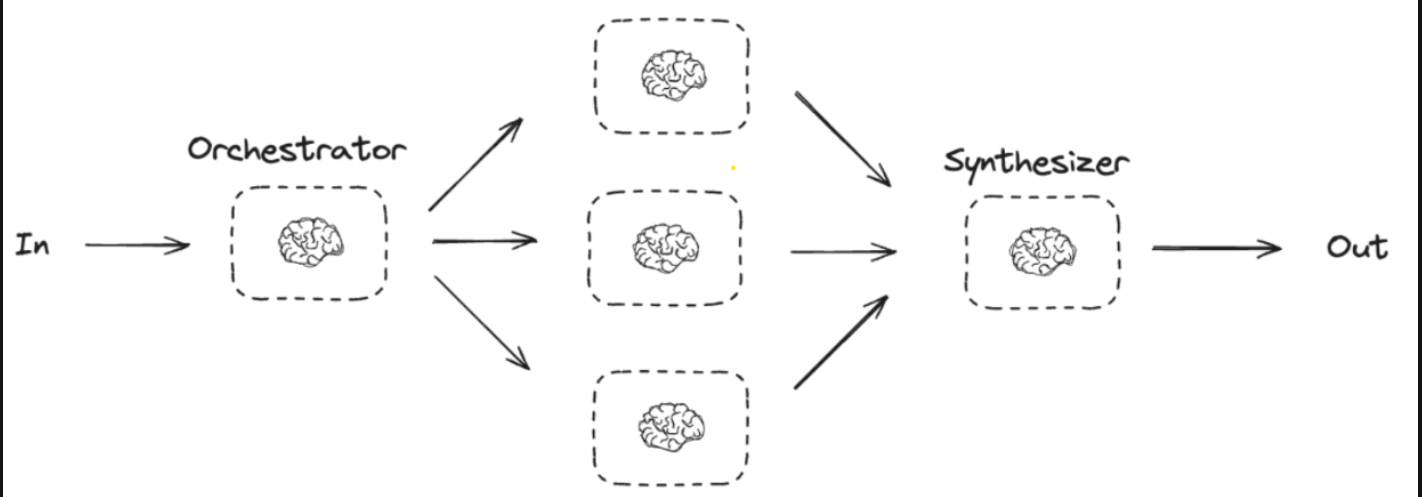

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="llama-3.3-70b-versatile")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.012927234, 'completion_tokens_details': None, 'prompt_time': 0.001735505, 'prompt_tokens_details': None, 'queue_time': 0.062293194, 'total_time': 0.014662739}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0c98-75d6-7363-bb6d-cf8c16c3b841-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [2]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

In [3]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [6]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [7]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

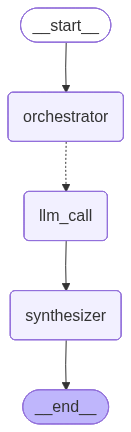

In [9]:
# Build workflow
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [10]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on How AI is helping developers"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction to AI in Development', description='Overview of AI and its increasing role in development'), Section(name='AI-powered Coding Tools', description='Discussion of AI-based tools that assist in coding, such as code completion and debugging'), Section(name='AI-driven Project Management', description='Explanation of how AI is used in project management, including task assignment and timeline prediction'), Section(name='AI-based Testing and Quality Assurance', description='Description of AI-powered testing tools and their impact on quality assurance'), Section(name='Future of AI in Development', description='Speculation on the future role of AI in development and potential advancements')]


### Introduction to AI in Development
Artificial Intelligence (AI) has revolutionized the way we live, work, and interact with one another. **Overview of AI**: AI refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as learning, problem-solving, and decision-making. 
#### Increasing Role of AI in Development
The increasing role of AI in development can be seen in various areas, including:
* **Automation**: AI-powered automation is being used to streamline processes, improve efficiency, and reduce costs in various industries, such as manufacturing, healthcare, and finance.
* **Data Analysis**: AI is being used to analyze large amounts of data, providing insights and patterns that can inform decision-making and drive innovation.
* **Smart Infrastructure**: AI is being integrated into infrastructure development, such as smart cities, to improve public services, enhance safety, and reduce environmental impact.
* **Social Impact**: AI is being used to address social and economic challenges, such as poverty, inequality, and access to education and healthcare.
The integration of AI in development has the potential to drive significant economic growth, improve living standards, and enhance the overall well-being of individuals and communities.

---

### AI-powered Coding Tools
AI-powered coding tools have revolutionized the way developers write, debug, and maintain code. These tools utilize artificial intelligence and machine learning algorithms to provide features such as:
* **Code Completion**: AI-powered code completion tools can predict and suggest the next line of code, reducing the time spent on typing and minimizing errors.
* **Debugging**: AI-based debugging tools can analyze code, identify errors, and provide recommendations for fixing them, streamlining the debugging process.
* **Code Review**: AI-powered code review tools can examine code for quality, security, and performance issues, helping developers improve their code before it reaches production.
* **Code Generation**: AI-based code generation tools can create boilerplate code, reducing the time spent on routine coding tasks and allowing developers to focus on more complex problems.
* **Code Optimization**: AI-powered code optimization tools can analyze code performance, identify bottlenecks, and provide recommendations for improvement, resulting in faster and more efficient code.

The benefits of AI-powered coding tools include:
* **Increased Productivity**: By automating routine coding tasks and providing intelligent suggestions, AI-powered coding tools can significantly reduce development time.
* **Improved Code Quality**: AI-powered coding tools can help developers write higher-quality code by detecting errors, suggesting improvements, and providing best practices.
* **Enhanced Collaboration**: AI-powered coding tools can facilitate collaboration among developers by providing a shared understanding of code quality, security, and performance.

However, there are also challenges and limitations associated with AI-powered coding tools, such as:
* **Dependence on Data Quality**: AI-powered coding tools require high-quality data to learn and improve, which can be a challenge in environments with limited or noisy data.
* **Lack of Transparency**: AI-powered coding tools can be opaque, making it difficult for developers to understand the reasoning behind the suggestions or recommendations.
* **Security Concerns**: AI-powered coding tools can introduce new security risks if not properly configured or maintained, such as vulnerabilities in the tool itself or dependencies on untrusted libraries.

---

### AI-driven Project Management
AI is revolutionizing the field of project management by increasing efficiency, accuracy, and productivity. One of the key applications of AI in project management is **task assignment**. AI algorithms can analyze the skills and workload of team members, and assign tasks accordingly. This ensures that each team member is working on tasks that match their strengths and expertise, leading to better outcomes and increased job satisfaction.

Another significant application of AI in project management is **timeline prediction**. AI algorithms can analyze historical data and real-time project metrics to predict the likelihood of meeting deadlines. This enables project managers to identify potential roadblocks and take proactive measures to mitigate risks. AI-powered predictive analytics can also help project managers to identify the most critical tasks and allocate resources accordingly.

Additionally, AI can help project managers to **monitor progress**, **identify bottlenecks**, and **optimize resource allocation**. AI-powered tools can analyze large amounts of data, including project schedules, budgets, and resource utilization, to provide insights and recommendations. This enables project managers to make data-driven decisions and take corrective actions to ensure project success.

Overall, AI-driven project management has the potential to transform the way projects are planned, executed, and delivered. By leveraging AI and machine learning, project managers can increase efficiency, reduce costs, and improve outcomes, leading to greater customer satisfaction and business success.

---

### AI-based Testing and Quality Assurance
AI-powered testing tools have revolutionized the quality assurance process by increasing efficiency, reducing costs, and improving test coverage. These tools utilize machine learning algorithms and artificial intelligence to automate testing, identify defects, and predict potential issues. Some of the key features of AI-powered testing tools include:
* **Test case generation**: AI algorithms can generate test cases based on the application's code, reducing the time and effort required to create test cases.
* **Test automation**: AI-powered tools can automate testing, including functional, performance, and security testing, reducing the need for manual testing.
* **Defect prediction**: AI algorithms can analyze data from previous tests and predict potential defects, allowing developers to identify and fix issues before they become major problems.
* **Test optimization**: AI-powered tools can optimize test scripts, reducing the time and resources required for testing.
The impact of AI-powered testing tools on quality assurance is significant, with benefits including:
* **Increased test coverage**: AI-powered tools can test a wider range of scenarios and edge cases, improving overall test coverage.
* **Faster time-to-market**: Automated testing and defect prediction enable developers to release software faster, reducing the time and cost associated with manual testing.
* **Improved accuracy**: AI algorithms can detect defects and issues that may be missed by human testers, improving the overall quality of the software.
* **Reduced costs**: Automated testing and defect prediction can reduce the costs associated with manual testing, defect fixing, and maintenance.

---

### Future of AI in Development
The future of AI in development holds tremendous promise, with potential advancements expected to revolutionize the way we design, build, and interact with software systems. 
#### Potential Advancements
* **Increased Automation**: AI is likely to play a significant role in automating repetitive and mundane tasks, freeing up developers to focus on more complex and creative tasks.
* **Intelligent Code Completion**: AI-powered code completion tools will become more sophisticated, enabling developers to write code more efficiently and with fewer errors.
* **Predictive Maintenance**: AI will be used to predict and prevent errors, reducing downtime and improving overall system reliability.
* **Personalized Development Environments**: AI will enable the creation of personalized development environments, tailored to individual developers' needs and preferences.
#### Speculation on Future Role
As AI continues to evolve, it is likely to take on a more prominent role in the development process, potentially leading to:
* **AI-Driven Design**: AI will be used to drive the design of software systems, using machine learning algorithms to create optimal system architectures and user interfaces.
* **Autonomous Development**: AI will be used to develop software systems autonomously, with minimal human intervention required.
* **Human-AI Collaboration**: AI will be used to collaborate with human developers, enhancing their capabilities and productivity.
* **New Programming Paradigms**: AI will enable the creation of new programming paradigms, such as neural network-based programming, which will require significant changes to the way we develop software.